# Problem Statement
Performing data analystics on kaggle's dataset titled "AI Usage and Student Academic Performance Analysis".
## Questions asked:
1. Which year of study has the highest ai dependency?
2.  Are users of AI more anxious than non-AI user?s

In [135]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind
print("Setup Complete")

Setup Complete


In [146]:
reviews=pd.read_csv("C:/Users/Rohan/Desktop/datasets/aiusage/data/ai_student_impact_dataset.csv")
reviews.shape
reviews.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


# Data Cleaning 
finding null values in columns(stated below) and replacing it with it's mean
1. Pre_Semester_GPA
2. Weekly_GenAI_Hours
3. Perceived_AI_Dependency

In [17]:
reviews[pd.isnull(reviews.Pre_Semester_GPA)]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [19]:
reviews[pd.isnull(reviews.Weekly_GenAI_Hours)]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [21]:
reviews[pd.isnull(reviews.Perceived_AI_Dependency)]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


# Exploratory Analysis
## 0. Number of students in each year

In [30]:
groups=reviews.groupby('Year_of_Study').Perceived_AI_Dependency.count()
groups.head()

Year_of_Study
Freshman     11031
Graduate      7430
Junior       11045
Senior       10634
Sophomore     9860
Name: Perceived_AI_Dependency, dtype: int64

## 1. Which year has highest ai usage

In [15]:
highestAIUsage=reviews
groups=highestAIUsage.groupby('Year_of_Study').Perceived_AI_Dependency.mean()
groups=groups.reset_index()
groups.loc[groups.Perceived_AI_Dependency==groups.Perceived_AI_Dependency.max()].Year_of_Study

4    Sophomore
Name: Year_of_Study, dtype: object

## 2. Are users of AI more anxious than non-AI users

In [21]:
low_ai_usage_anxiety=reviews.loc[reviews.Perceived_AI_Dependency<3].Anxiety_Level_During_Exams.mean()
high_ai_usage_anxiety=reviews.loc[reviews.Perceived_AI_Dependency>=3].Anxiety_Level_During_Exams.mean()
high_ai_usage_anxiety>low_ai_usage_anxiety

True

## 3. Does anxiety increase with AI usage?
Using t-test

In [137]:
high=reviews.loc[reviews.Perceived_AI_Dependency>=3, 'Anxiety_Level_During_Exams']
low=reviews.loc[reviews.Perceived_AI_Dependency<3, 'Anxiety_Level_During_Exams']
ttest_ind(high, low)

TtestResult(statistic=49.71610596762625, pvalue=0.0, df=49998.0)

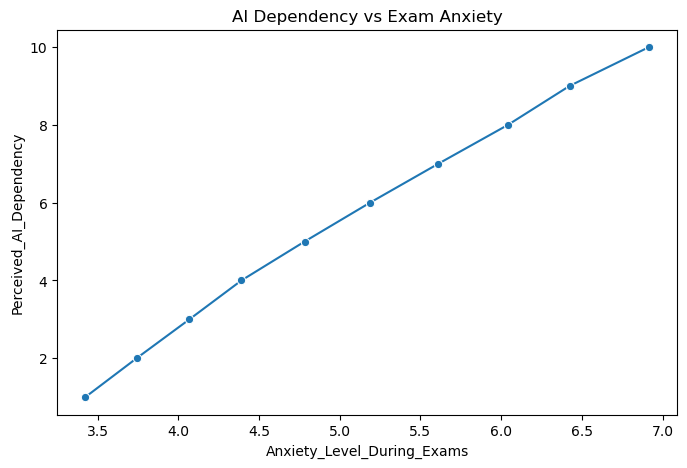

In [69]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=anxietydata,
    y='Perceived_AI_Dependency',
    x='Anxiety_Level_During_Exams',
    marker='o'
)
plt.title("AI Dependency vs Exam Anxiety")
plt.show()

## 4. Relation of AI usage with GPA

In [63]:
gpadata=reviews.groupby('Perceived_AI_Dependency')[['Pre_Semester_GPA', 'Post_Semester_GPA']].mean().reset_index()
gpadata.head()

,Perceived_AI_Dependency,Pre_Semester_GPA,Post_Semester_GPA
0,1,3.142011,3.344685
1,2,3.149917,3.354801
2,3,3.145493,3.355664
3,4,3.143324,3.351380
4,5,3.151954,3.359899


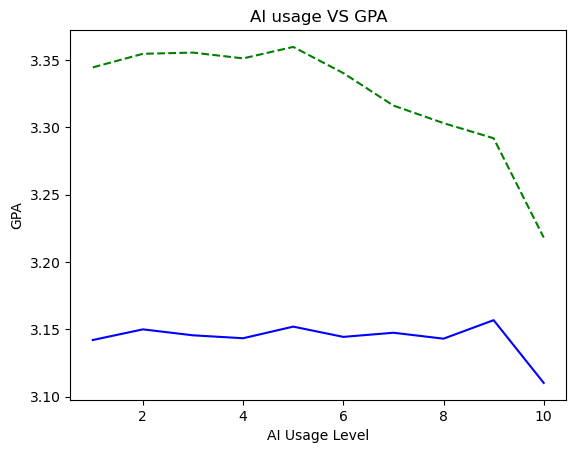

In [65]:
plt.plot(gpadata.Perceived_AI_Dependency, gpadata.Pre_Semester_GPA, label="Pre_Semester_GPA", color="blue", linestyle="-")
plt.plot(gpadata.Perceived_AI_Dependency, gpadata.Post_Semester_GPA, label="Post_Semester_GPA", color="green", linestyle="--")
plt.title("AI usage VS GPA")
plt.xlabel("AI Usage Level")
plt.ylabel("GPA")
plt.show()

## 5. GPA Improvement with AI Usage

In [117]:
gpachange=(reviews.Post_Semester_GPA-reviews.Pre_Semester_GPA).groupby(reviews.Perceived_AI_Dependency).mean().reset_index()
gpachange=gpachange.rename(columns={0: 'gpa_difference'})
gpachange.head()

,Perceived_AI_Dependency,gpa_difference
0,1,0.202674
1,2,0.204884
2,3,0.210171
3,4,0.208057
4,5,0.207944


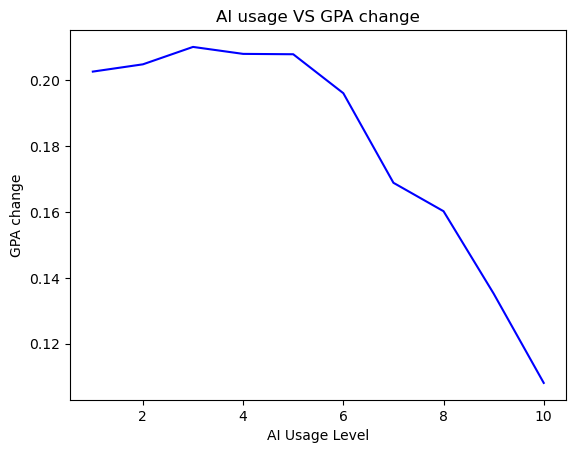

In [121]:
plt.plot(gpachange.Perceived_AI_Dependency, gpachange.gpa_difference, color="blue", linestyle="-")
plt.title("AI usage VS GPA change")
plt.xlabel("AI Usage Level")
plt.ylabel("GPA change")
plt.show()

## 6. Burnout Analysis

<Axes: xlabel='Burnout_Risk_Level', ylabel='count'>

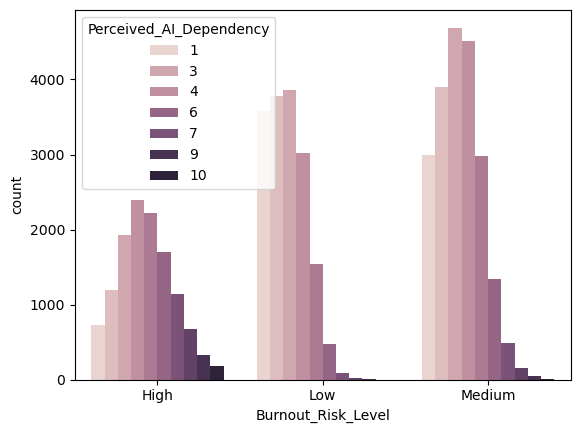

In [126]:
sns.countplot(
    data=reviews,
    x='Burnout_Risk_Level',
    hue='Perceived_AI_Dependency'
)

## 7. Correlation Analysis

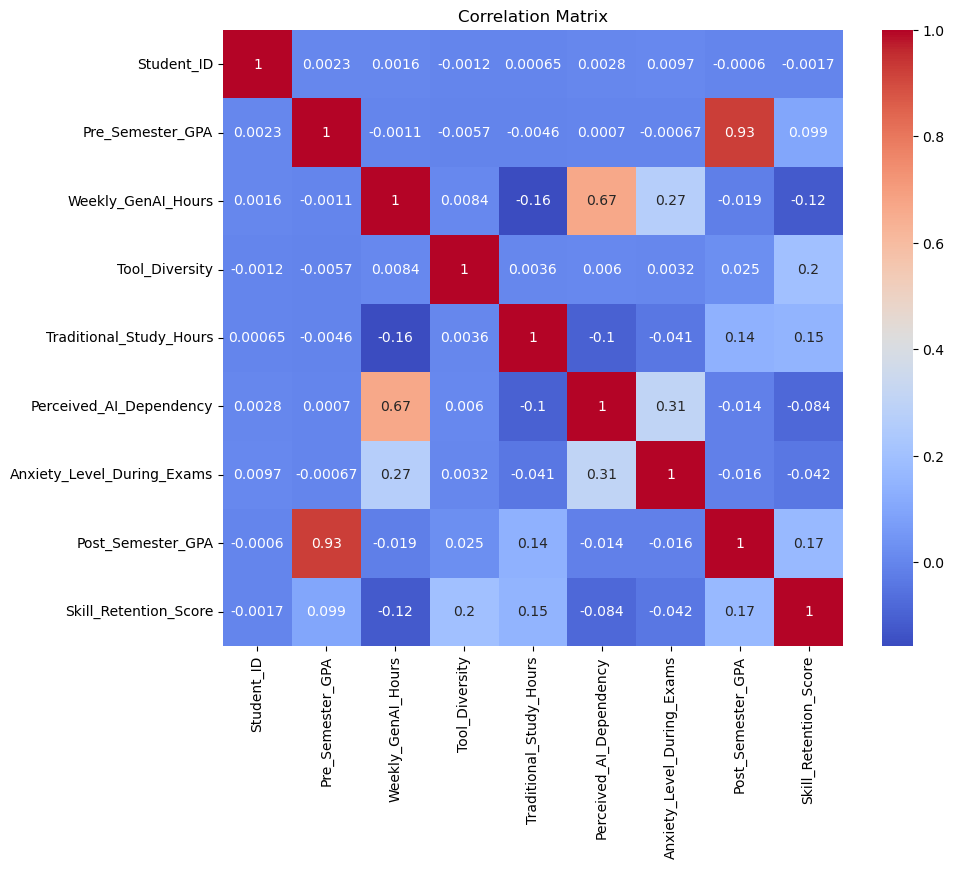

In [140]:
numeric_cols=reviews.select_dtypes(include='number')
corr=numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Insights
1. Sophomores show highest AI usage.
2. AI users showed higher exam time anxiety than non-AI users
3. Students with higher AI dependency exhibited significantly different anxiety levels during exams compared to students with lower AI dependency (t = 49.72, p < 0.001). The difference is statistically significant.
4. Students across all AI dependency levels showed similar GPA performance. While post-semester GPA was consistently higher than pre semester GPA.
5. GPA improvement was observed across all groups.
6. Students with greater AI dependency tended to appear more often in higher burnout categories, suggesting a possible relationship between AI usage and burnout risk.